# Predicción de Fraude en Transacciones (Fraud Detection Dataset)

**Proyecto de Data Science — Clasificación Binaria**

Este notebook desarrolla un pipeline completo de Data Science sobre el dataset *Fraud Detection Dataset* (6,3 millones de registros de transacciones financieras), con el objetivo de identificar operaciones potencialmente fraudulentas en un futuro.

**Contenido:**
1. Entendimiento del problema y los datos
2. Análisis Exploratorio de Datos (EDA)
3. Limpieza y preprocesamiento
4. Feature Engineering
5. Modelado (Regresión Logística, Random Forest, XGBoost)
6. Evaluación
7. Interpretación y conclusiones

## 1. Entendimiento del problema y los datos

**Pregunta de negocio:** ¿Podemos identificar si una transacción es potencialmente fraudulenta a partir de sus características?

**Variable objetivo:** `isFraud` (1 = transacción fraudulenta, 0 = transacción legítima) → problema de **clasificación binaria**.

## 2. Análisis Exploratorio de Datos (EDA)

### 2.1. Exploración inicial del dataset

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [8]:
df = pd.read_csv('../data/crudo/AIML Dataset.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [9]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 6362620
Columnas: 11


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


**Hallazgos iniciales:**

- El dataset contiene 6,362,620 transacciones y 11 variables.
- Presenta variables numéricas y categóricas, correspondientes a características de las transacciones, saldos y variables de identificación.
- La variable objetivo `isFraud` es de tipo entero y representa la clasificación de la transacción como fraudulenta o no fraudulenta.
- La variable `isFlaggedFraud` también es de tipo entero y corresponde a una variable de marcado de posibles operaciones fraudulentas.
- El dataset tiene un tamaño considerable, con un uso aproximado de 706.2 MB en memoria, por lo que será necesario considerar el consumo de recursos durante el procesamiento.

In [13]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [16]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

**Hallazgo:** La variable objetivo `isFraud` presenta un marcado desbalance de clases. De las 6,362,620 transacciones, 6,354,407 (99.87%) corresponden a operaciones no fraudulentas y 8,213 (0.13%) a operaciones fraudulentas. Este desbalance deberá ser considerado durante el entrenamiento y evaluación de los modelos.

In [15]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

**Hallazgo:** La variable `isFlaggedFraud` presenta una distribución altamente concentrada en la clase 0, con 6,362,604 registros, frente a solo 16 registros con valor 1.

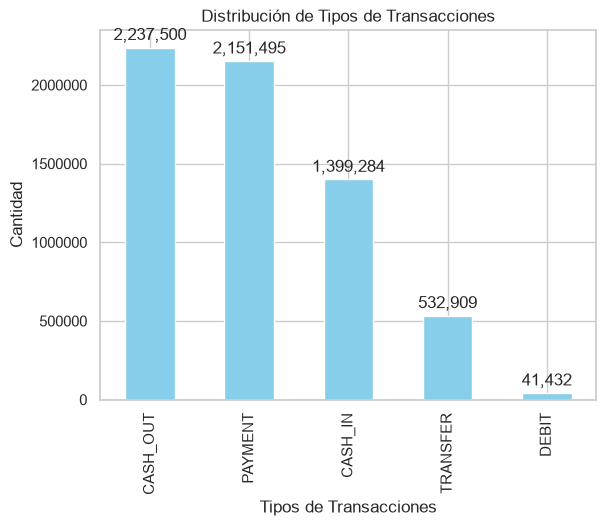

In [22]:
ax = df["type"].value_counts().plot(kind='bar', title='Distribución de Tipos de Transacciones', color='skyblue')
plt.xlabel('Tipos de Transacciones')
plt.ylabel('Cantidad')
for container in ax.containers:
    labels = [f'{int(bar.get_height()):,}' for bar in container]
    ax.bar_label(container, labels=labels, padding=3)
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=90)
plt.show()

**Hallazgo:** Las transacciones se concentran principalmente en los tipos `CASH_OUT` y `PAYMENT`, mientras que `DEBIT` presenta la menor cantidad de operaciones. `TRANSFER` y `CASH_IN` tienen una participación intermedia dentro del conjunto de datos.

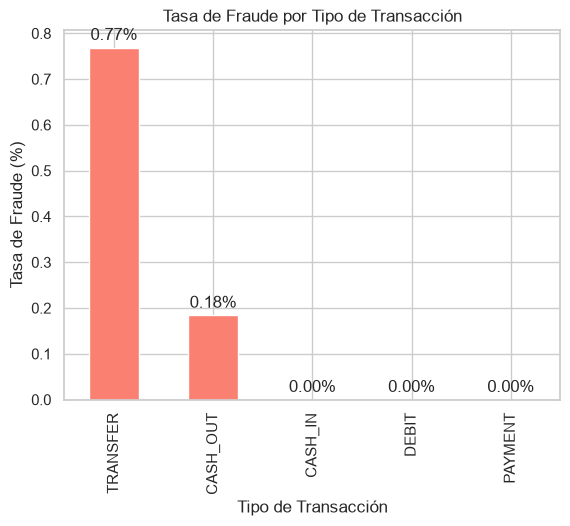

In [31]:
fraud_by_type = df.groupby('type')['isFraud'].mean() * 100
fraud_by_type = fraud_by_type.sort_values(ascending=False)

ax = fraud_by_type.plot(kind='bar',title='Tasa de Fraude por Tipo de Transacción',color='salmon')

plt.xlabel('Tipo de Transacción')
plt.ylabel('Tasa de Fraude (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.show()

**Hallazgo:** Las transacciones `TRANSFER` presenta la mayor tasa de fraude, con aproximadamente 0.77%, seguidas por `CASH_OUT` con 0.18%. Los tipos `CASH_IN`, `DEBIT` y `PAYMENT` presentan tasas inferiores, que se redondean a 0.00% en el gráfico.

### 2.2. Calidad de los datos

In [33]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df.select_dtypes(include='number').min()

step              1.0
amount            0.0
oldbalanceOrg     0.0
newbalanceOrig    0.0
oldbalanceDest    0.0
newbalanceDest    0.0
isFraud           0.0
isFlaggedFraud    0.0
dtype: float64

**Hallazgo:** El dataset no presenta valores nulos ni registros duplicados. Se identifican valores cero en algunas variables numéricas, los cuales serán evaluados según el contexto de cada variable.


### 2.3. Análisis estadístico descriptivo

In [42]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

**Hallazgo:** El monto de las transacciones presenta una alta dispersión, con una mediana de 74,871 y un máximo de 92,445,516, evidenciando valores extremos que deberán evaluarse durante el análisis de outliers.


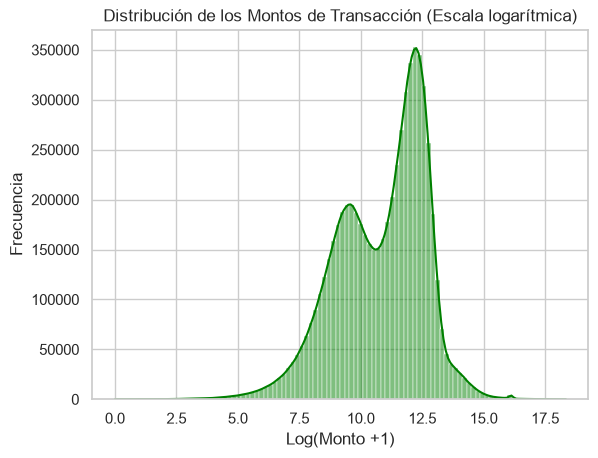

In [43]:
sns.histplot(np.log1p(df['amount']), bins=100, kde=True, color='green')
plt.title('Distribución de los Montos de Transacción (Escala logarítmica)')
plt.xlabel('Log(Monto +1)')
plt.ylabel('Frecuencia')
plt.show()

**Hallazgo:** La distribución del monto (en escala log) es bimodal, con dos picos claros alrededor de log(monto)≈9.5-10 y ≈12-12.5. Esto sugiere la coexistencia de dos grupos de transacciones con comportamiento distinto, en lugar de una única población homogénea de transacciones.

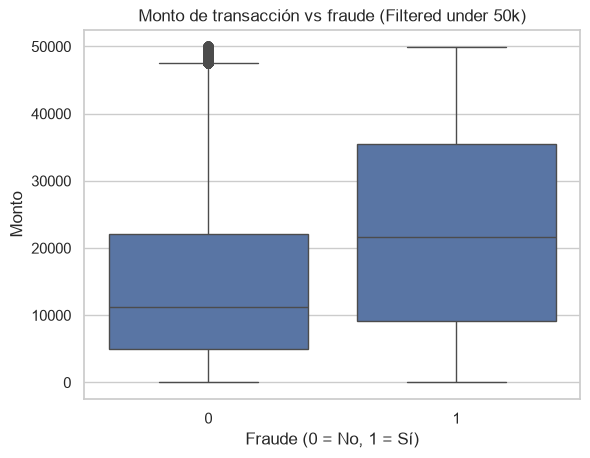

In [45]:
sns.boxplot(data=df[df['amount'] < 50000], x='isFraud', y='amount')
plt.title('Monto de transacción vs fraude (Filtered under 50k)')
plt.xlabel('Fraude (0 = No, 1 = Sí)')
plt.ylabel('Monto')
plt.show()

**Hallazgo:** Las transacciones fraudulentas tienden a tener montos más altos y más dispersos que las transacciones normales. La mediana del monto en transacciones fraudulentas 21,000 aprox. casi duplica a la de las no fraudulentas con 11,000 aprox. , y su rango intercuartílico es más amplio, es decir el fraude no se concentra en un monto típico, varía más.

### 2.4. Comportamiento de saldos

In [49]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [50]:
(df["balanceDiffOrig"] < 0).sum()

np.int64(1399253)

In [48]:
(df["balanceDiffDest"] < 0).sum()

np.int64(1238864)

In [51]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


### 2.5. Evolución temporal del fraude

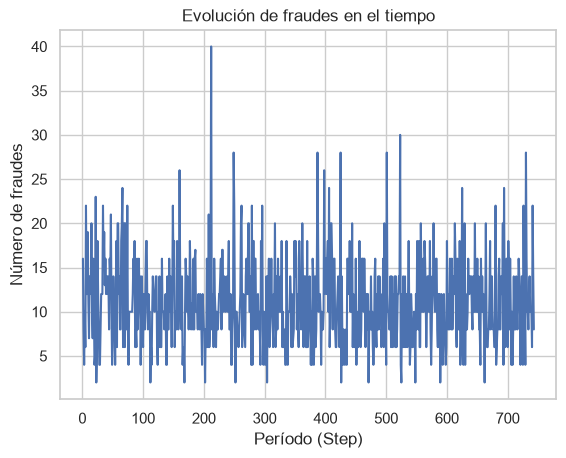

In [ ]:
frauds_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()

plt.plot(frauds_per_step.index, frauds_per_step.values, label="Fraudes por período")

plt.xlabel("Período (Step)")
plt.ylabel("Número de fraudes")
plt.title("Evolución de fraudes en el tiempo")
plt.grid(True)

plt.show()

**Hallazgo:** la columna `step` no muestra una relación clara con el fraude ya que el número de casos se mantiene estable en el tiempo, sin tendencia. Además, al ser un contador secuencial de la simulación, mantenerlo arriesga que el modelo memorice períodos específicos en vez de aprender patrones de comportamiento reales. Por ambas razones, se elimina la columna.

In [53]:
df.drop(columns="step", inplace=True)
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


### 2.6. Análisis de cuentas origen y destino

In [55]:
top_senders = df["nameOrig"].value_counts().head(10)
top_senders

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
C1976208114    3
C1784010646    3
C1530544995    3
C1902386530    3
C1677795071    3
Name: count, dtype: int64

In [56]:
top_receivers = df["nameDest"].value_counts().head(10)
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [57]:
fraud_users = df[df['isFraud'] == 1]['nameOrig'].value_counts().head(10)
fraud_users

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

### 2.7. Tipo de Transacción

In [58]:
fraud_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]
fraud_types["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

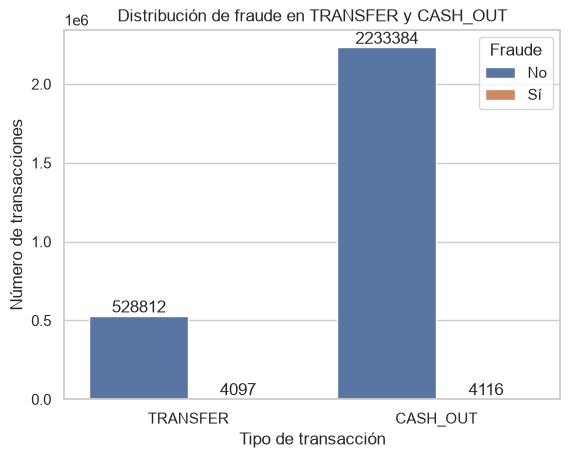

In [ ]:
ax = sns.countplot(data=fraud_types, x="type", hue="isFraud")
plt.title("Distribución de fraude en TRANSFER y CASH_OUT")
plt.xlabel("Tipo de transacción")
plt.ylabel("Número de transacciones")
plt.legend(title="Fraude", labels=["No", "Sí"])
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
plt.show()

**Hallazgo:** Las transacciones `CASH_OUT` presentan un mayor volumen de operaciones y concentran 4,116 casos de fraude, mientras que `TRANSFER` registra 4,097 casos fraudulentos. Aunque CASH_OUT tiene mayor cantidad total de transacciones, ambos tipos presentan una cantidad similar de operaciones fraudulentas.

### 2.8. Correlación entre variables

In [61]:
corr = df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


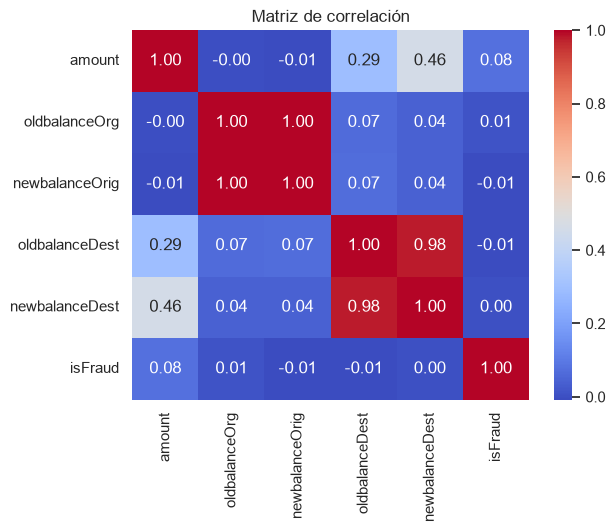

In [63]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

In [64]:
zero_after_transfer = df[
    (df['oldbalanceOrg'] > 0) &
    (df['newbalanceOrig'] == 0) & 
    (df['type'].isin(['TRANSFER', 'CASH_OUT']))
]


In [65]:
len(zero_after_transfer)

1188074

In [66]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89
